# **Лабораторная работа 1. Асимптотика. Бинарный поиск. Линейные алгоритмы.**

**Предварительная подготовка.**

**СКОПИРУЙТЕ ФАЙЛ**

Даньшина Василиса

Сдаете в LMS вы ipynb версию скачанную (не colab). При необходимости, вы можете сдать дополнительно файл (офомленный в любом читаемом виде).

Пожалуйста, не надо использовать ИИ для ответов на вопросы и написания кода. Отвечать на вопросы лучше прям здесь, под заданиями, где были написаны вопросыю

# 1. Изучите ```perf_counter()``` и ```perf_counter_ns()```.

`perf_counter()` и `perf_counter_ns()` — это функции из модуля `time`, предоставляющие **доступ к высокоточным таймерам**.

Посмотрите на пример измерения времени работы какого-то фрагмента кода.

In [4]:
import time

# perf_counter() — возвращает время в СЕКУНДАХ (float)
start = time.perf_counter()
s = sum(range(100000))  # некоторый измеряемый фрагмент кода
end = time.perf_counter()
print(end - start)

# perf_counter_ns() — возвращает время в НАНОСЕКУНДАХ (int)
start_ns = time.perf_counter_ns()
s = sum(range(100000)) # некоторый измеряемый фрагмент кода
end_ns = time.perf_counter_ns()
print(end_ns - start_ns)

0.0023847420000038255
2862140


# 2. Как проводить измерение времени работы алгоритма и глубины рекурсии (для рекурсивных алгоритмов)

Напишем простую рекурсивную функцию для подсчета факториала числа. И на её примере посмотрим как измерять время работы алгоритма, а также глубину рекурсии.

In [5]:
import sys
sys.setrecursionlimit(10000)
def factorial(n):
    if n <= 1:
        return 1
    return n * factorial(n-1)

Проведем анализ сложности этой функции.

Для нее верно следующее рекуррентное соотношение
```
T(n) = T(n-1) + O(1)
T(1) = O(1)
```

Выполним процесс развертывания рекурсивной функции.

```
T(n) = T(n-1) + 1
T(n) = [T(n-2) + 1] + 1 = T(n-2) + 2
T(n) = [T(n-3) + 1] + 2 = T(n-3) + 3
```

**на шаге k получим**
```
T(n) = T(n-k) + k
```
При k = n-1 достигнем базового случая (доходим до T(1)):

```
T(n) = T(1) + (n-1)
T(n) = 1 + (n-1)
T(n) = n
```

**Временная сложность:** **O(n)** — линейная

## Анализ времени (через функцию измерения времени)

Напишем функцию, которая измеряет время работы этой функции на разных размерах входных данных, чтобы на реальных замерах убедиться, что время работы функции линейное.

In [6]:
def measure_factorial_time(n, repeats=10): # repeats число повторов для одной сессии измерений
    times = []

    for _ in range(repeats):
        start = time.perf_counter_ns()
        result = factorial(n)
        end = time.perf_counter_ns()
        times.append(end - start)

    # убираем выбросы (минимальное и максимальное время) и усредняем
    if repeats > 2:
        times.sort()
        times = times[1:-1]

    avg_time = sum(times) / len(times)
    return avg_time, result

times_ns = [] # тут будет время работы
init_n = list(range(100, 1001, 50)) # тут будут исходные размеры входных данных

for n in init_n:
    time_ns, _ = measure_factorial_time(n, repeats=10)
    times_ns.append(time_ns)

Теперь визуализируем результаты, чтобы на графике убедиться в корректности наших выводов о времени работы функции.

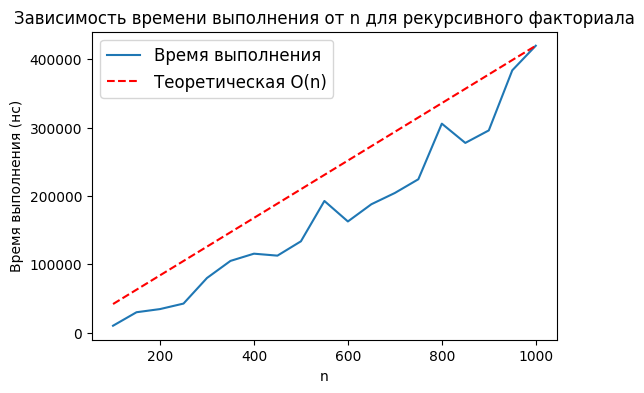

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(init_n, times_ns, label='Время выполнения')


import numpy as np
theoretical_log = [n for n in init_n]
scale_factor = max(times_ns) / max(theoretical_log)
theoretical_time = [t * scale_factor for t in theoretical_log]
plt.plot(init_n, theoretical_time, 'r--', label='Теоретическая O(n)')


plt.xlabel('n')
plt.ylabel('Время выполнения (нс)')
plt.title('Зависимость времени выполнения от n для рекурсивного факториала')
plt.legend(fontsize=12, loc='upper left')

Измерение времени зависит от множества факторов: загрузки процессора, фоновых процессов, и даже (внезапно!) температуры CPU и т.д. Сегодня алгоритм выполняется 1.2 мс, завтра -- 1.5 мс, и непонятно, что изменилось. Поэтому используют еще один подход -- измеряют количество операций. Ведь количество операций -- детерминировано: для факториала 5 всегда будет 5 умножений.

## Анализ времени (через измерение числа операций)

Перепишем функцию факториала, чтобы можно было измерить число операций. К сожалению, придется немного испортить нашу функцию.

In [8]:
def factorial(n):
    def _fact(n):
        nonlocal operations
        operations += 1  # каждая проверка условия - операция
        if n <= 1:
            return 1
        operations += 3
        # умножение, вычитание и вызов функции это еще три операции
        return n * _fact(n-1)

    operations = 0
    result = _fact(n)
    return result, operations

In [9]:
def count_factorial_operations(n, repeats=10):
    times = []
    result = None

    for _ in range(repeats):
        result, ops = factorial(n)

    return result, ops

init_n = list(range(100, 1001, 50))
times_ns = []
operations_list = []

for n in init_n:
    _, ops = count_factorial_operations(n, repeats=10)
    operations_list.append(ops)

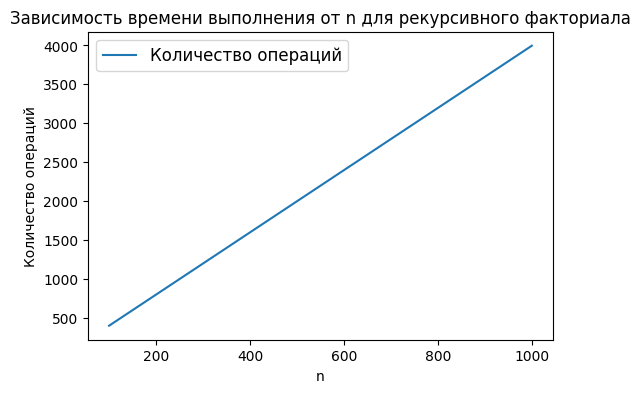

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(init_n, operations_list, label='Количество операций')

plt.xlabel('n')
plt.ylabel('Количество операций')
plt.title('Зависимость времени выполнения от n для рекурсивного факториала')
plt.legend(fontsize=12, loc='upper left')

Обратите внимание, на графике нет выбросов и зависимость более четкая. Также не нужно выполнять несколько повторов.

## Анализ глубины рекурсии

Перепишем функцию, чтобы можно было измерить максимальную глубину рекурсии

In [11]:
def factorial(n):
    def _fact(n, depth):
        nonlocal max_depth
        max_depth = max(max_depth, depth)

        if n <= 1:
            return 1

        return n * _fact(n-1, depth + 1)

    max_depth = 0
    result = _fact(n, 1)  # начинаем с глубины 1
    return result, max_depth

init_n = list(range(100, 1001, 50))
depth_list = []

for n in init_n:
    _, depth = factorial(n)
    depth_list.append(depth)

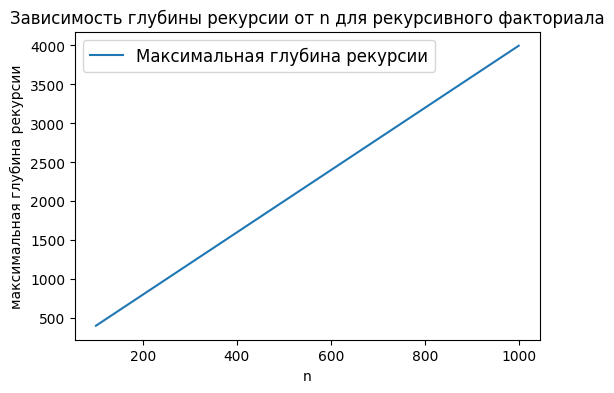

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.plot(init_n, operations_list, label='Максимальная глубина рекурсии')

plt.xlabel('n')
plt.ylabel('максимальная глубина рекурсии')
plt.title('Зависимость глубины рекурсии от n для рекурсивного факториала')
plt.legend(fontsize=12, loc='upper left')

Фактически, в данном примере, для нас глубина рекурсии показывает количество используемой памяти. Видим, что максимальная глубина рекурсии линейно зависит от размера входных данных. Учитывая, что на каждом вызове у нас создается/копируется константное количество переменных -- память используемая (то есть пространтсвенная сложность) **O(N)**

# Задание 1 (4 балла). Левосторонний бинарный поиск

**Левосторонний бинарный поиск (leftmost binary search)** -- ищет первое вхождение элемента в отсортированном массиве. Если элемент встречается несколько раз, возвращает индекс самого левого (минимального) вхождения.

### Предварительная подготовка

1. Реализовать наивную рекурсивную функцию левостороннего бинарного поиска в отсортированном массиве.
2. Реализовать наивную итеративную функцию левостороннего бинарного поиска в отсортированном массиве.
3.  Вывести асимптотическую сложность алгоритма **методом развертывания рекуррентного соотношения** (записать рекуррентное соотношение для T(n), выполнить пошаговое развертывание, получить формулу и итоговую асимптотику), для обоих реализаций.

In [13]:
# Реализация рекурсивной функции левостороннего бинарного поиска
def left_binary_search_recursive(arr, target, left, right, result=-1, count=0, depth=0):
    count += 1
    depth += 1
    if left > right:
        return result, count, depth
    mid= (left+right) // 2
    if arr[mid] == target:
        return left_binary_search_recursive(arr, target, left, mid-1, mid, count, depth)
    elif arr[mid] < target:
        return left_binary_search_recursive(arr, target, mid+1, right, result, count, depth)
    else:
        return left_binary_search_recursive(arr, target, left, mid-1, result, count, depth)

In [14]:
# Реализация итеративного левостороннего бинарного поиска
def left_binary_search_iterative(arr, target):
    left= 0
    right = len(arr)-1
    result = -1
    count = 0
    while left <= right:
        count += 1
        mid = (left+right) // 2
        if arr[mid] == target:
            result = mid
            right = mid-1
        elif arr[mid] < target:
            left = mid+1
        else:
            right = mid-1
    return result, count

Асимптотическую сложность алгоритма:
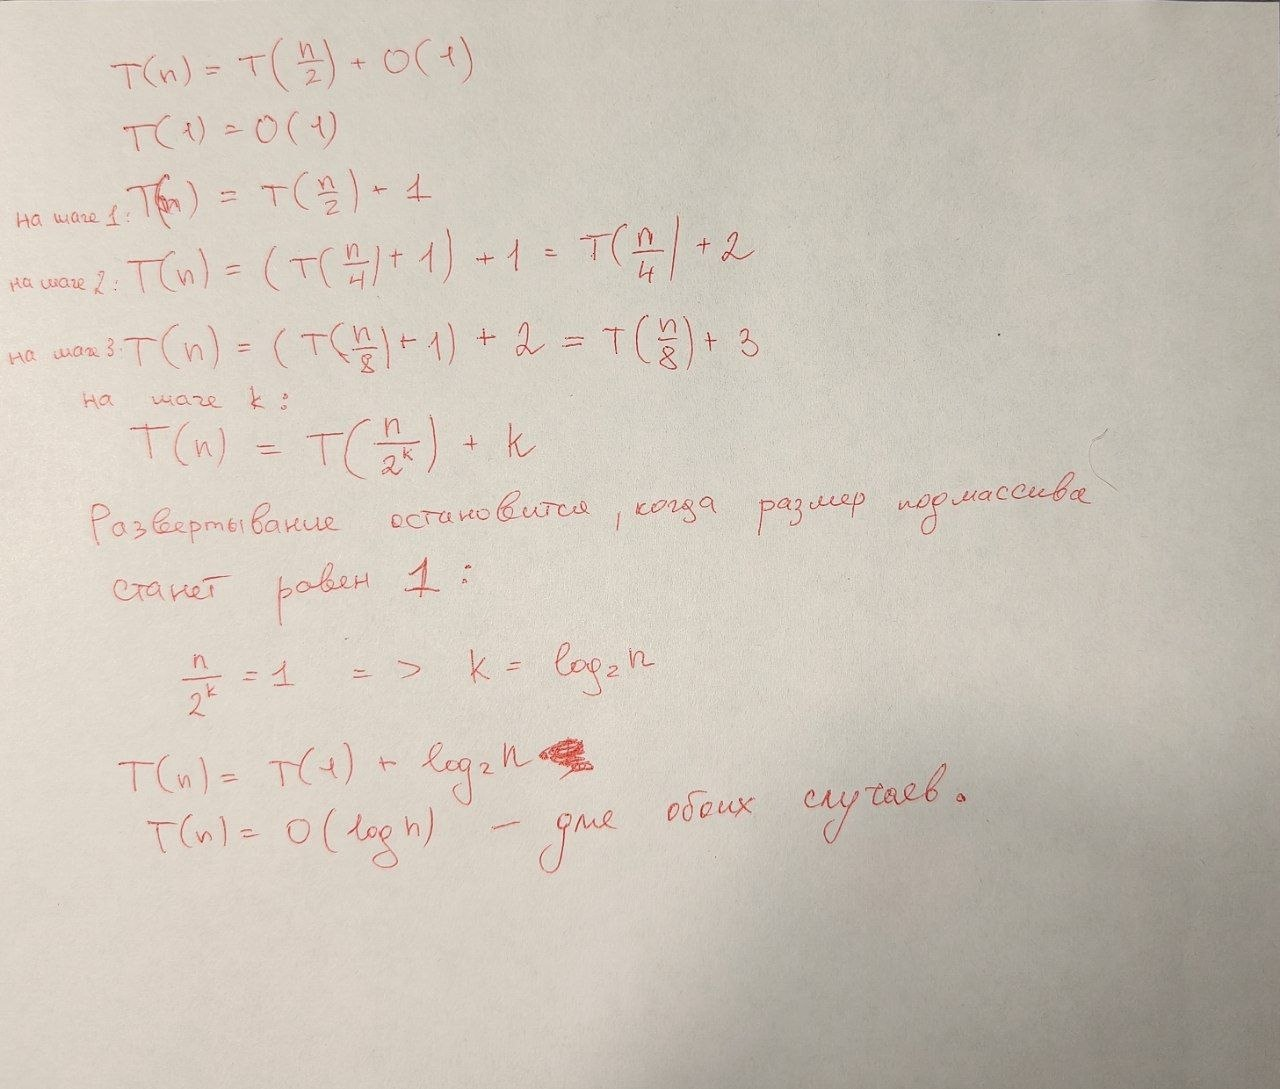


### Провести эксперименты

5. Взять для экспериментов размеры массивов от 100 до 5000 с шагом 100.
6. Сгенерировать (определить) три типа входных данных для каждого размера массива (лучший случай, средний случай, худший случай).
7. Для каждого кадого алгоритма, каждого размера массива и каждого типа случая:
  * Подсчитать среднее время выполнения (выполнить не менее 10 повторных замеров для усреднения времени)
  * Подсчитать количество операций
  * Подсчитать максимальную глубину рекурсии

In [15]:
sizes = range(100, 5100, 100)
results = []
for n in sizes:
    arr = list(range(n))
    cases = {
        "Best": n//2,
        "Worst": -1,
        "Normal": n//4
    }
    for case_name, target in cases.items():
        # для итеративного
        iter_times=[]
        for _ in range(10):
            start = time.perf_counter_ns()
            res_idx, count_count = left_binary_search_iterative(arr, target)
            iter_times.append(time.perf_counter_ns() - start)

        avg_time_iter = sum(iter_times)/len(iter_times)

        # для рекурсивного
        rec_times=[]
        for _ in range(10):
            start = time.perf_counter_ns()
            res_idx, count_rec, depth_rec = left_binary_search_recursive(arr, target, 0, len(arr)-1)
            rec_times.append(time.perf_counter_ns() - start)

        avg_time_rec = sum(rec_times)/len(rec_times)

        results.append({
            "Размер": n,
            "Случай": case_name,
            "Время_итеративная": avg_time_iter,
            "Количество_итеративная": count_count,
            "Время_рекурсивная": avg_time_rec,
            "Количество_рекурсивная": count_rec,
            "Глубина_рекурсивная": depth_rec
        })

In [16]:
import pandas as pd
df = pd.DataFrame(results)
print(df)

     Размер  Случай  Время_итеративная  Количество_итеративная  \
0       100    Best             1804.8                       6   
1       100   Worst             1153.5                       6   
2       100  Normal             1108.2                       6   
3       200    Best             1254.5                       7   
4       200   Worst             1207.2                       7   
..      ...     ...                ...                     ...   
145    4900   Worst             2009.8                      12   
146    4900  Normal             2354.4                      12   
147    5000    Best             2274.9                      12   
148    5000   Worst             1988.0                      12   
149    5000  Normal             2226.3                      12   

     Время_рекурсивная  Количество_рекурсивная  Глубина_рекурсивная  
0               2131.0                       7                    7  
1               1590.8                       7                    7

### Построить графики

8. На одном графике отобразить зависимости среднего времени работы (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией. Для обоих алгоритмов.
9. На одном графике отобразить зависимости количества операций (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией. Для обоих алгоритмов.
10. На одном графике отобразить зависимости глубины рекурсии (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией. Для обоих алгоритмов.

**Требования к графикам:**

Сделайте
* Подписи осей
* Заголовок
* Легенду с пояснением всех линий


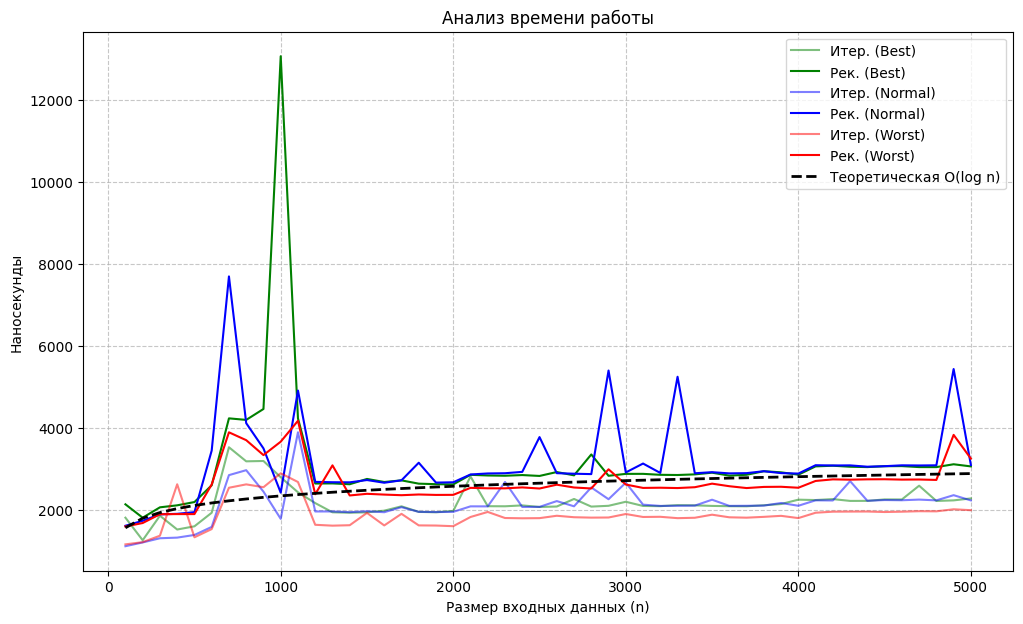

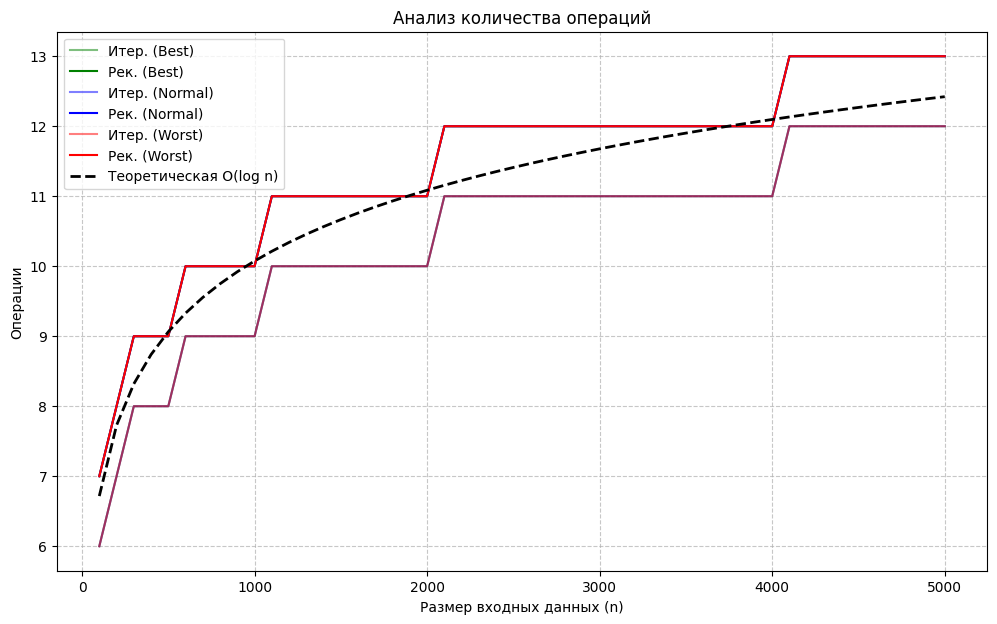

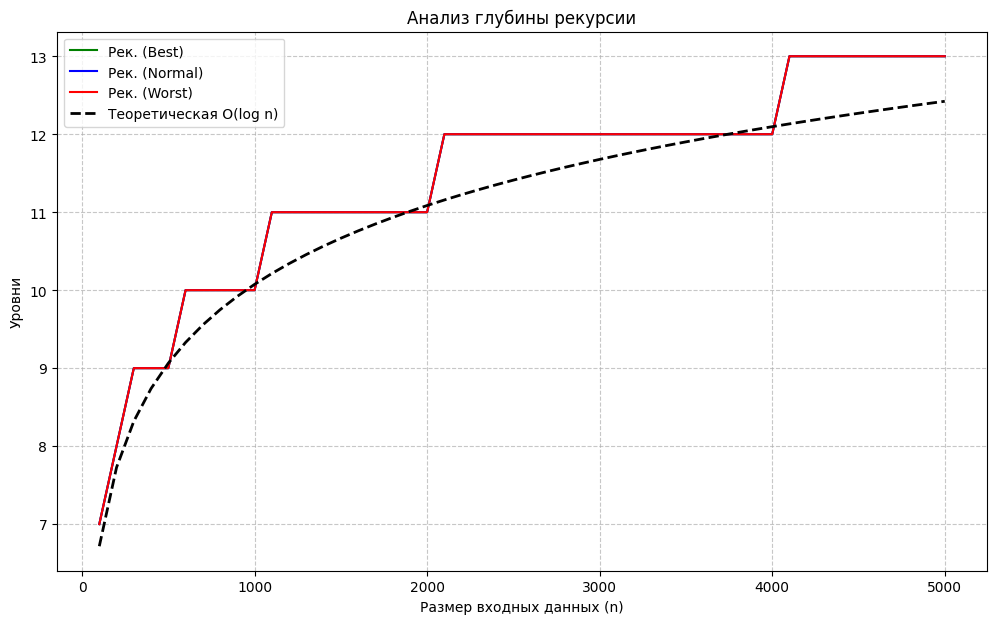

In [17]:
df = pd.DataFrame(results)
sizes = sorted(df["Размер"].unique())
def plot_results(metric_prefix, title, ylabel, is_recursion_only=False):
    plt.figure(figsize=(12, 7))
    colors= {"Best": "green", "Normal": "blue", "Worst": "red"}
    sample_data = df[(df["Случай"] == "Worst")][f"{metric_prefix}_рекурсивная"]
    scale = sample_data.mean() / np.log2(np.median(sizes))

    for case in ["Best", "Normal", "Worst"]:
        case_data = df[df["Случай"] == case]

        if not is_recursion_only:
            col_name_iter = f"{metric_prefix}_итеративная"
            plt.plot(case_data["Размер"], case_data[col_name_iter],
                     label=f"Итер. ({case})", color=colors[case], alpha=0.5)

        col_name_rec = f"{metric_prefix}_рекурсивная"
        plt.plot(case_data["Размер"], case_data[col_name_rec],
                 label=f"Рек. ({case})", color=colors[case])

    theoretical = [scale * np.log2(n) for n in sizes]
    plt.plot(sizes, theoretical, label="Теоретическая O(log n)", color="black", linestyle="--", linewidth=2)

    plt.title(title)
    plt.xlabel("Размер входных данных (n)")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

plot_results("Время", "Анализ времени работы", "Наносекунды")
plot_results("Количество", "Анализ количества операций", "Операции")
plot_results("Глубина", "Анализ глубины рекурсии", "Уровни", is_recursion_only=True)

### Анализ результатов + ответы на вопросы

1. Сравните теоретическую асимптотику с экспериментальными данными. Совпадает ли форма кривых?
2. Сравнить рекурсивную и итеративную версии. Какая быстрее? Почему?
3. Сравнить рекурсивную и итеративную версии с точки зрения использования памяти (пространстенной сложности).
4. Объяснить разницу между лучшим, средним и худшим случаями. Когда какой случай наступает? Почему?
5. Почему при измерении времени работы функции на графике наблюдались выбросы? Какие способы его избежать существуют?

Ответы на вопросы:
1. Теоретическая сложность бинарного поиска составляет O(logn). На графиках количества операций и глубины рекурсии видная ступенчатая логарифмическая кривая. Это полностью совпадает с теорией, так как количество делений массива пополам растет крайне медленно относительно роста n. На графике времени общая тенденция также логарифмическая, однако линия сильно зашумлена ( видны зубцы и выбросы). Это связано с тем как исполняется код, а не с алгоритмической сложностью.

2. Исходя из данных в таблице и графиков, итеративная версия работает быстрее, хотя разница в наносекундах может казаться незначительной на малых данных. Когда мы вызываем функцию внутри функции (рекурсия), системе приходится каждый раз создавать пакет с данными. Это куча лишних операций. А цикл просто гоняет одни и те же переменные по кругу, это намного легче для процессора.

3. Итеративная версия использует О(1) дополнительной памяти. Независимо от размера массива n, нам нужно всего несколько переменных (left, right, mid, result).

Рекурсивная версия же использует О(log n)памяти, что довольно затратно. По сути каждый рекурсивный шаг создается новый кадр в стеке вызовов. Для таких масштабов это не очень критично, но при огромных n рекурсия может привести к переполнению стека (RecursionError).

4. Худший случай - Элемента нет в массиве или он находится в самом конце процесса деления. Количество операций максимально.

 Лучший случай - В обычном бинарном поиске это нахождение элемента за 1 шаг (в центре). Но в данном случае даже если элемент в центре, алгоритм все равно пойдет проверять левую часть до конца. Поэтому количество операций в лучшем и худшем случаях почти одинаково (разница в 1-2 итерации).

  Средний случай - искомый элемент где-то недалево от середины.

5. Причины выбросов на графике времени:

* Фоновые процессы ОС: Процессор может  отвлечься на обновление системы или работу другого приложения.
* Внезапный запуск сборщика мусора Python.
* Изменение частоты процессора из-за нагрева.

Способы этого избежать:
* Увеличить количества повторов
* Отбрасывать самый быстрый и самый медленный результаты перед усреднением
* Использование медианы вместо среднего, так как она более устойчива к выбросам

# Задание 2 (3 балла). Модификация бинарного поиска

Представьте, что алгоритм бинарного поиска был изменен. На каждом шаге массив делится на 3 части.

**Принцип работы**
1. Массив делится на три части двумя точками: mid1 и mid2
2. Сравниваем искомый элемент с значениями в этих точках
3. В зависимости от результата, продолжаем поиск в одной из трех частей

Будем искать также, самое первое вхождение элемента.

### Предварительная подготовка

1. Реализовать такую версию бинарного поиска.
2.  Вывести асимптотическую сложность алгоритма **методом развертывания рекуррентного соотношения** (записать рекуррентное соотношение для T(n), выполнить пошаговое развертывание, получить формулу и итоговую асимптотику).

In [18]:
def three_search_recursive(arr, target, left, right, result=-1, count=0, current_depth=0, max_depth=0):
    count += 1
    current_depth += 1
    max_depth = max(max_depth, current_depth)

    if left > right:
        return result, count, max_depth

    mid1 = left+(right-left) // 3
    mid2 = right-(right-left) // 3

    if arr[mid1] == target:
        return three_search_recursive(arr, target, left, mid1-1, mid1, count, current_depth, max_depth)

    elif arr[mid2] == target:
        return three_search_recursive(arr, target, left, mid2-1, mid2, count, current_depth, max_depth)

    elif target < arr[mid1]:
        return three_search_recursive(arr, target, left, mid1-1, result, count, current_depth, max_depth)
    elif target > arr[mid2]:
        return three_search_recursive(arr, target, mid2+1, right, result, count, current_depth, max_depth)
    else:
        return three_search_recursive(arr, target, mid1+1, mid2-1, result, count, current_depth, max_depth)

Асимптотика данного поиска:
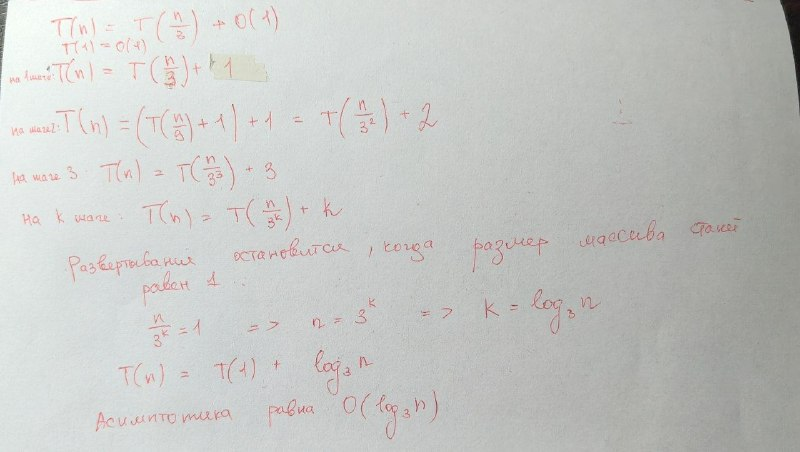

### Провести эксперименты

4. Взять для экспериментов размеры массивов от 100 до 5000 с шагом 100.
5. Сгенерировать (определить) три типа входных данных для каждого размера массива (лучший случай, средний случай, худший случай).
6. Для каждого размера массива и каждого типа случая:
  * Подсчитать среднее время выполнения (выполнить не менее 10 повторных замеров для усреднения времени)
  * Подсчитать количество операций
  * Подсчитать максимальную глубину рекурсии

In [19]:
sizes = range(100, 5100, 100)
results_three_search = []

for n in sizes:
    arr = list(range(n))
    cases = {
        "Best": arr[n//3],
        "Worst": -1,
        "Normal": n//4
    }

    for case_name, target in cases.items():
        times = []
        for _ in range(10):
            start= time.perf_counter_ns()
            res, ops, depth = three_search_recursive(arr, target, 0, len(arr) - 1)
            times.append(time.perf_counter_ns() - start)

        results_three_search.append({
            "Размер": n,
            "Случай": case_name,
            "Время": sum(times) / len(times),
            "Операции": ops,
            "Глубина": depth
        })

df_three_search = pd.DataFrame(results_three_search)
print(df_three_search)

     Размер  Случай   Время  Операции  Глубина
0       100    Best  5258.2         5        5
1       100   Worst  5594.6         5        5
2       100  Normal  4784.5         6        6
3       200    Best  4672.5         6        6
4       200   Worst  7220.9         6        6
..      ...     ...     ...       ...      ...
145    4900   Worst  5844.6         9        9
146    4900  Normal  5614.5         9        9
147    5000    Best  7421.9         9        9
148    5000   Worst  4796.7         9        9
149    5000  Normal  4479.5         9        9

[150 rows x 5 columns]


### Построить графики

7. На одном графике отобразить зависимости среднего времени работы (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией.
8. На одном графике отобразить зависимости количества операций (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией.
9. На одном графике отобразить зависимости глубины рекурсии (лучший, средний, худший случаи разными цветами) от размера входных данных, а также теоретическую кривую O(log n) -- пунктирной линией.

**Требования к графикам:**

Сделайте
* Подписи осей
* Заголовок
* Легенду с пояснением всех линий


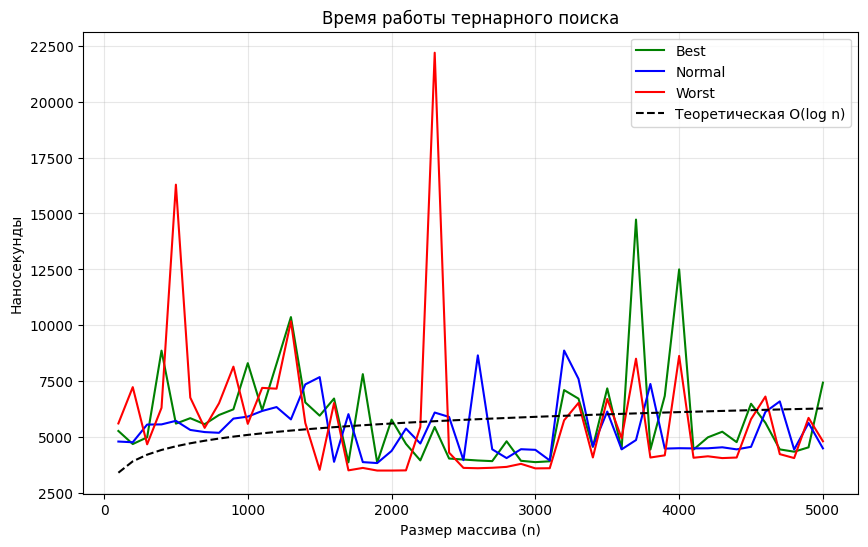

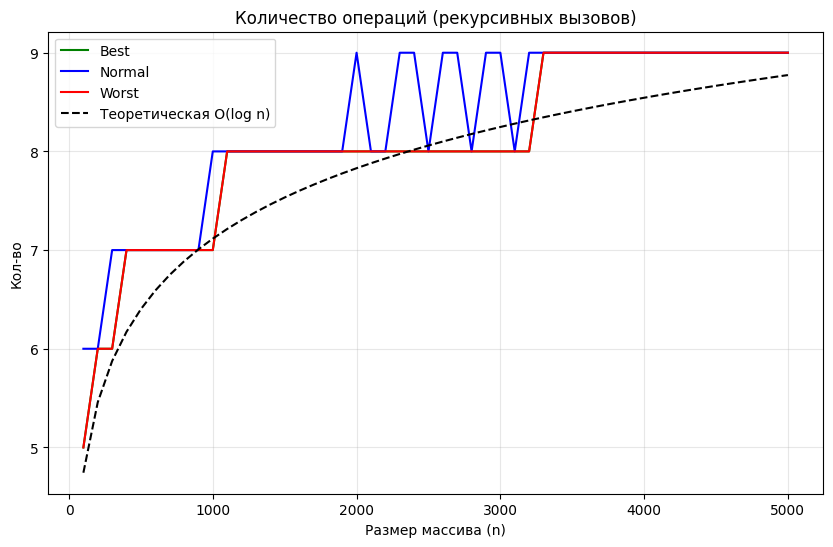

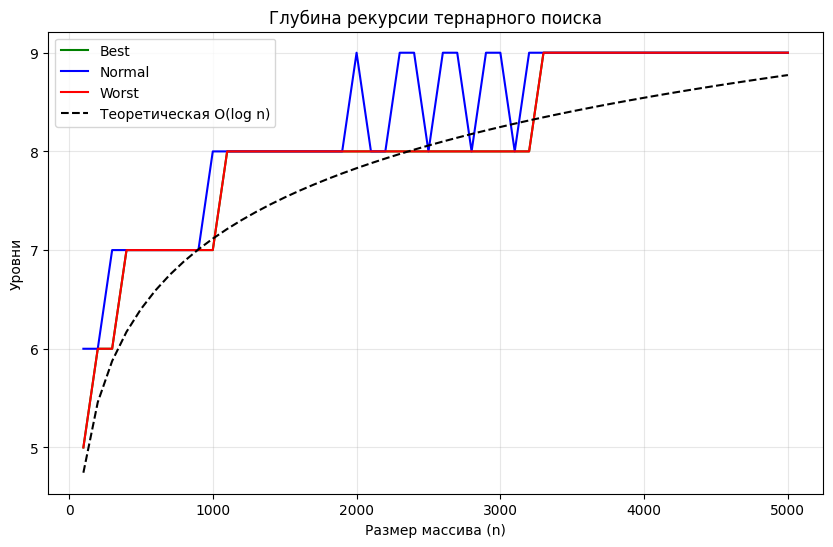

In [20]:
def plot_three_search(metric, title, ylabel):
    plt.figure(figsize=(10, 6))
    colors = {"Best": "green", "Normal": "blue", "Worst": "red"}

    for case in ["Best", "Normal", "Worst"]:
        data = df_three_search[df_three_search["Случай"] == case]
        plt.plot(data["Размер"], data[metric], label=f"{case}", color=colors[case])

    theory_scale= df_three_search[df_three_search["Случай"] == "Worst"][metric].mean() / np.log(np.median(list(sizes)))
    theoretical = [theory_scale*np.log(n) for n in sizes]
    plt.plot(sizes, theoretical, label="Теоретическая O(log n)", color="black", linestyle="--")

    plt.title(title)
    plt.xlabel("Размер массива (n)")
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_three_search ("Время", "Время работы тернарного поиска", "Наносекунды")
plot_three_search("Операции", "Количество операций (рекурсивных вызовов)", "Кол-во")
plot_three_search("Глубина", "Глубина рекурсии тернарного поиска", "Уровни")

### Анализ результатов + ответы на вопросы

1. Сравните теоретическую асимптотику с экспериментальными данными. Совпадает ли форма кривых?
2. Сравнить классический алгоритм и алгоритм с делением на три части. Какой лучше? Почему?
3. Объяснить разницу между лучшим, средним и худшим случаями. Когда какой случай наступает? Почему?
4. Почему при измерении времени работы функции на графике наблюдались выбросы? Какие способы его избежать существуют?

**Ответы на вопросы:**
1. Экспериментальные данные полностью подтверждают теоретическую асимптотику. На графиках количества операций и глубины рекурсии наблюдается характерная логарифмическая зависимость с наличием ступенчатой структуры. Это объясняется тем, что количество уровней рекурсии увеличивается на единицу только при кратном (в три раза) увеличении размера входного массива. Траектория экспериментальных точек совпадает с наложенной теоретической кривой O(log n).

2. Несмотря на то что поиск с двумя точками имеет меньшее количество итераций (основание логарифма 3, а не 2), в бинарном поиске на каждом шаге выполняется одно сравнение и одно вычисление середины, а в данном поиске необходимо вычислять две точки деления (mid1 и mid2) и выполнять до двух-трех проверок условий (if-elif-else), что менее эффективно. И в итоге общее время выполнения у бинарного поиска получается ниже, так как уменьшение количества шагов не может компенсировать вычислительную нагрузку в каждой итерации.

3. Худший случай - это когда искомый элемент отсутствует в массиве. Алгоритм проходит через максимально возможную глубину деления сегментов до тех пор, пока границы не схлопнутся.

Лучший случай - это когда искомый элемент находится сразу в одной из точек деления (mid1 или mid2).

Нормальный случай - случайное число где-то внутри массива.

Но так как целью является поиск самого левого элемента, алгоритм не прекращает работу при обнаружении совпадения. Вследствие этого глубина рекурсии и число операций в лучшем и худшем случаях становятся идентичными, что видно на графиках.

4. Причины выбросов на графике времени:

* Фоновые процессы ОС: Процессор может  отвлечься на обновление системы или работу другого приложения.
* Внезапный запуск сборщика мусора Python.
* Изменение частоты процессора из-за нагрева.

Способы этого избежать:
* Увеличить количества повторов
* Отбрасывать самый быстрый и самый медленный результаты перед усреднением
* Использование медианы вместо среднего, так как она более устойчива к выбросам

# Задание 3 (3 балла). Быстрое возведение в степень

В этом задании предстоит возвести число x в степень n, где n -- целое неотрицательное число.

## Предварительная подготовка

1. Реализовать простое наивное возведение в степень.
2. Реализовать быстрое возведение в степень.
3.  Вывести асимптотическую сложность алгоритма **методом развертывания рекуррентного соотношения** (записать рекуррентное соотношение для T(n), выполнить пошаговое развертывание, получить формулу и итоговую асимптотику). Для обоих методов.


In [21]:
# наивное возведение в степень
def naive_power(x, n, count=0, depth=0):
    count += 1
    depth += 1
    if n == 0:
        return 1, count, depth

    res, count, depth = naive_power(x, n-1, count, depth)
    return x*res, count, depth

In [22]:
# быстрое возведение в степень
def fast_power(x, n, count=0, depth=0):
    count += 1
    depth += 1
    if n == 0:
        return 1, count, depth

    if n % 2 == 0:
        # если четный n
        half_res, count, depth = fast_power(x, n//2, count, depth)
        return half_res*half_res, count, depth
    else:
        # если нечетный n
        res, count, depth = fast_power(x, n-1, count, depth)
        return x * res, ops, depth

Асимптотика наивного возведения: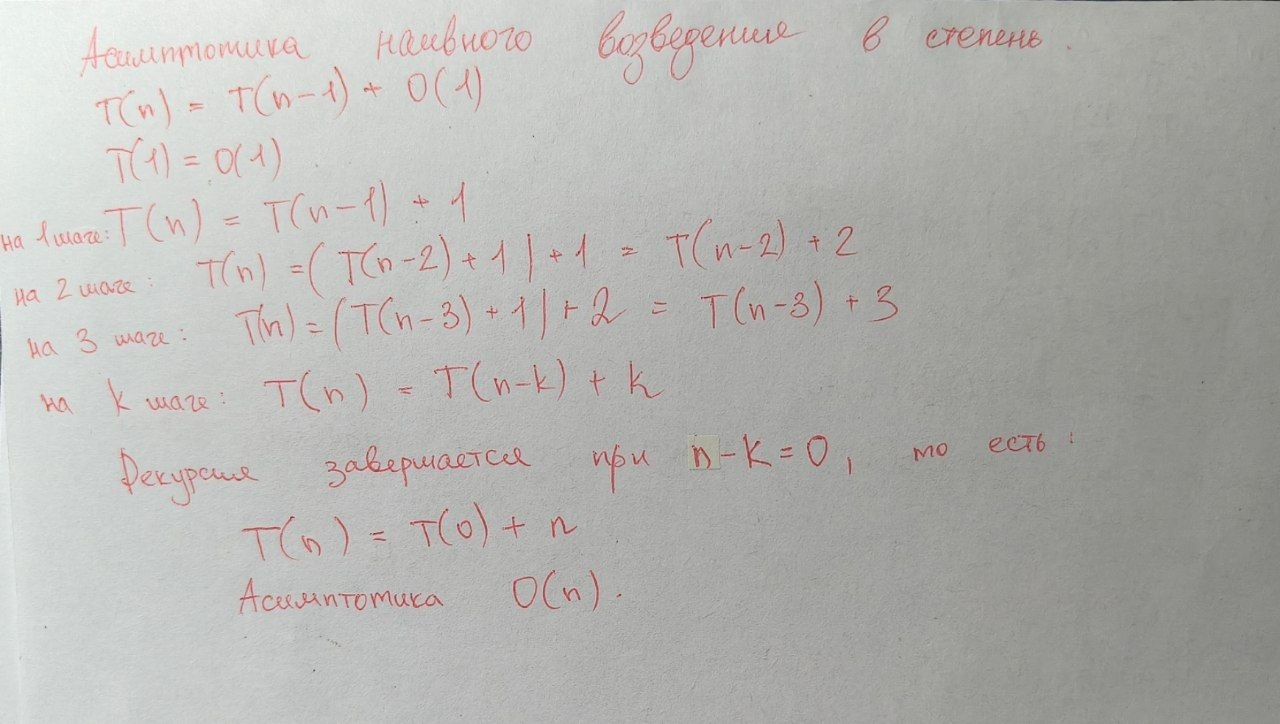

Асимптотика быстрого возведения: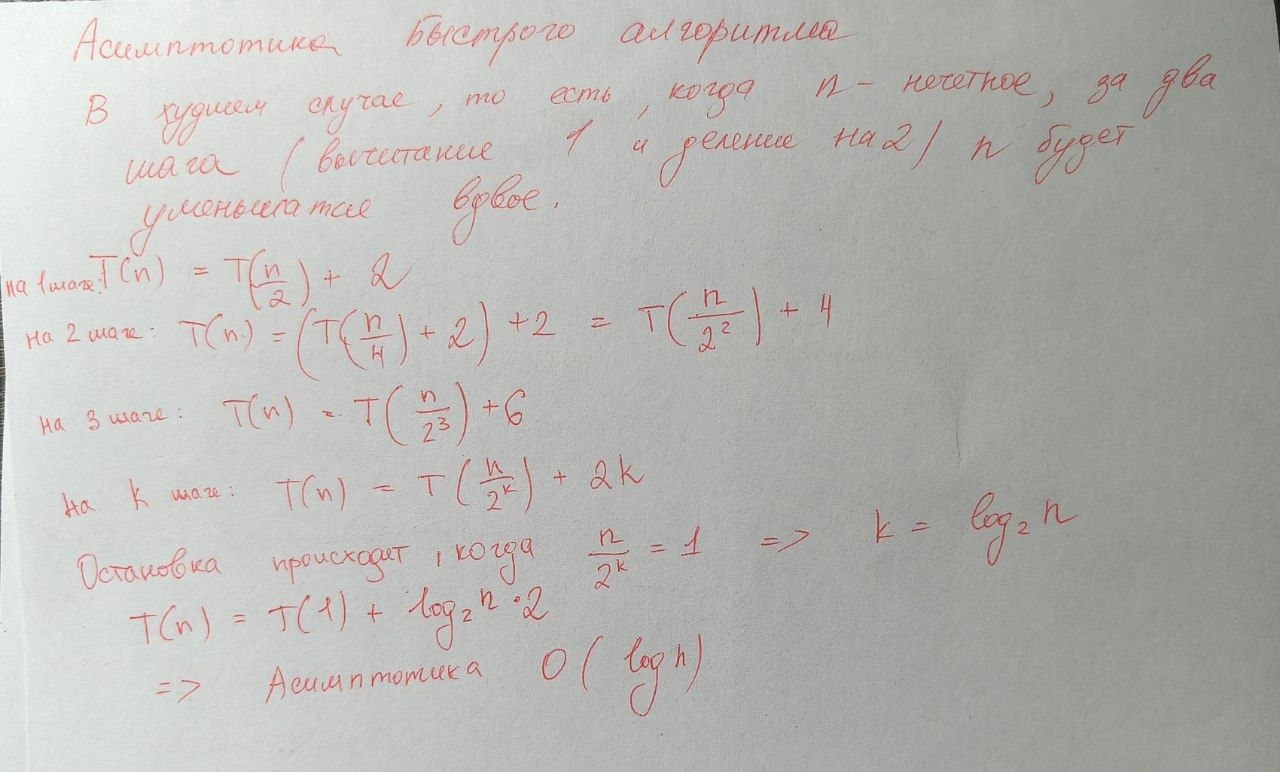

## Провести эксперименты

5. Взять для экспериментов степени от 10 до 1000 (основание 2).
6. Для каждого размера массива и каждого алгоритма:
  * Подсчитать среднее время выполнения (выполнить не менее 10 повторных замеров для усреднения времени)
  * Подсчитать количество операций
  * Подсчитать максимальную глубину рекурсии

In [24]:
ns = range(10, 1001, 10)
results_power = []

for n in ns:
    x = 2
    naive_times = []
    for _ in range(10):
        start = time.perf_counter_ns()
        _, count_n, depth_n = naive_power(x, n)
        naive_times.append(time.perf_counter_ns()-start)

    fast_times = []
    for _ in range(10):
        start = time.perf_counter_ns()
        _, count_f, depth_f = fast_power(x, n)
        fast_times.append(time.perf_counter_ns() - start)

    results_power.append({
        "n": n,
        "Время наивного": sum(naive_times) / 10,
        "Операции наивного": count_n,
        "Глубина наивного": depth_n,
        "Время быстрого": sum(fast_times) / 10,
        "Операции быстрого ": count_f,
        "Глубина быстрого": depth_f
    })

df_power = pd.DataFrame(results_power)
print(df_power)

       n  Время наивного  Операции наивного  Глубина наивного  Время быстрого  \
0     10          2344.7                 11                11          1636.1   
1     20          3262.9                 21                21          1575.0   
2     30          4712.6                 31                31          1899.3   
3     40          7898.9                 41                41          1952.9   
4     50          7894.5                 51                51          1936.1   
..   ...             ...                ...               ...             ...   
95   960        332741.6                961               961          3648.8   
96   970        319238.6                971               971          3976.8   
97   980        325420.4                981               981          3986.8   
98   990        326592.4                991               991          4390.8   
99  1000        330026.4               1001              1001          3922.7   

    Операции быстрого   Глу

## Построить графики

7. На одном графике отобразить зависимости среднего времени работы от размера входных данных
8. На одном графике отобразить зависимости количества операций
9. На одном графике отобразить зависимости глубины рекурсии

**Требования к графикам:**

Сделайте
* Подписи осей
* Заголовок
* Легенду с пояснением всех линий


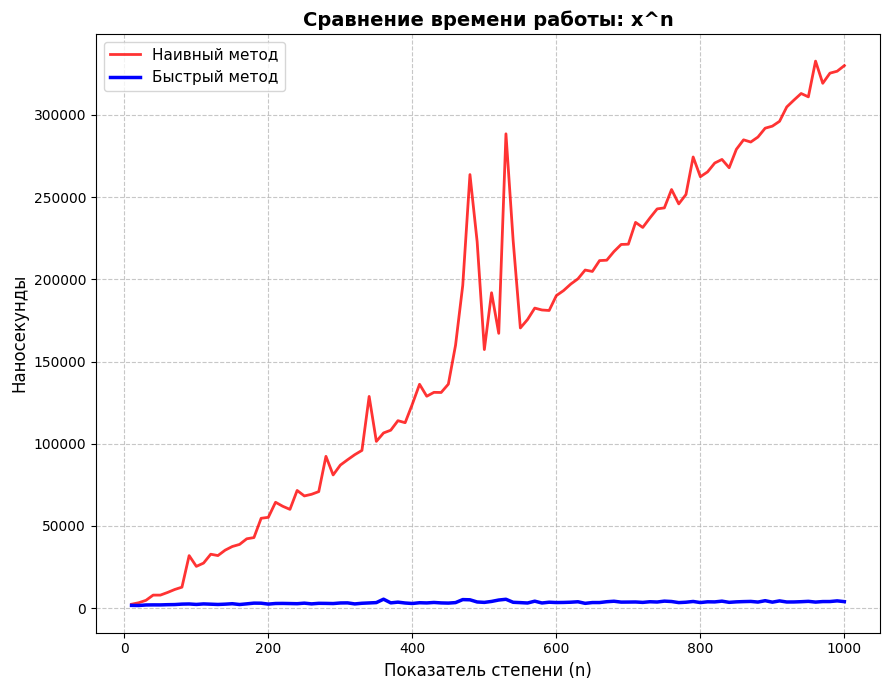

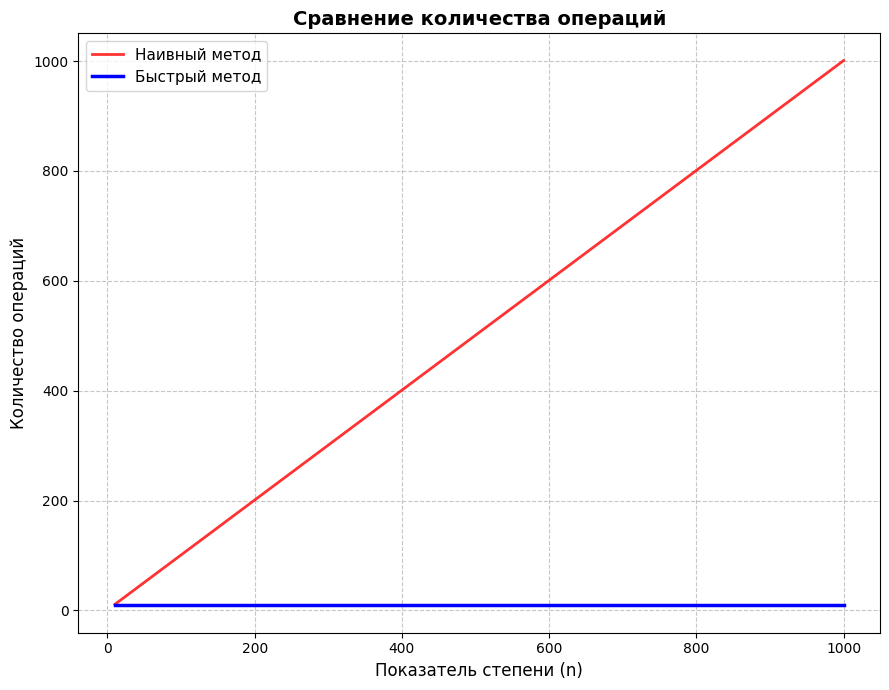

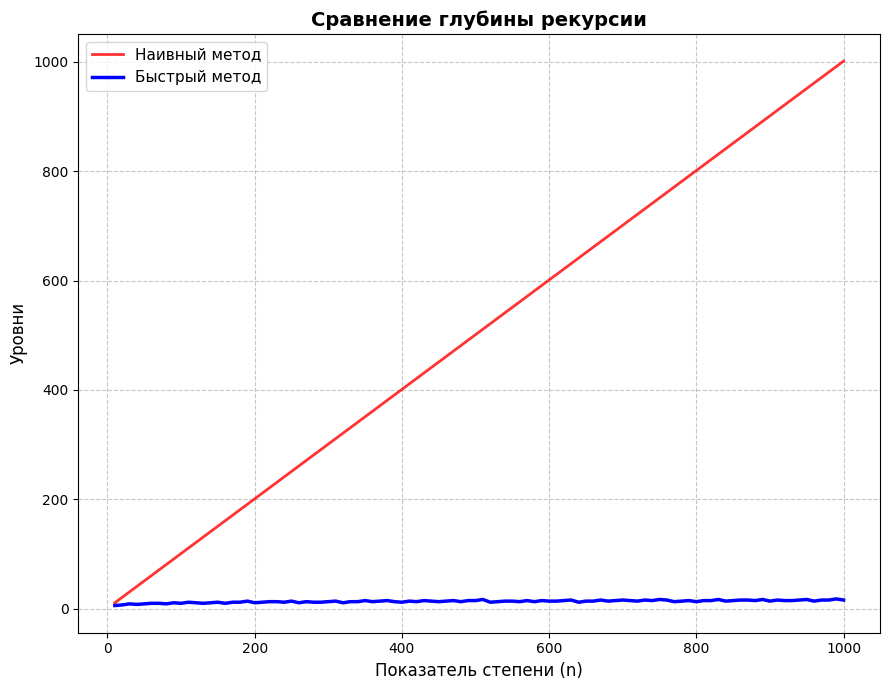

In [26]:
def plot_power_results(naive_col, fast_col, title, ylabel):
    """
    Универсальная функция для сравнения наивного и быстрого возведения в степень.
    """
    plt.figure(figsize=(9, 7))
    plt.plot(df_power["n"], df_power[naive_col],
             label=f"Наивный метод", color="red", linewidth=2, alpha=0.8)
    plt.plot(df_power["n"], df_power[fast_col],
             label=f"Быстрый метод", color="blue", linewidth=2.5)

    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel("Показатель степени (n)", fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

plot_power_results("Время наивного", "Время быстрого",
                   "Сравнение времени работы: x^n", "Наносекунды")
plot_power_results("Операции наивного", "Операции быстрого ",
                   "Сравнение количества операций", "Количество операций")
plot_power_results("Глубина наивного", "Глубина быстрого",
                   "Сравнение глубины рекурсии", "Уровни")

## Анализ результатов + ответы на вопросы

1. Сравните теоретическую асимптотику с экспериментальными данными. Совпадает ли форма кривых?
2. Сравнить классический алгоритм и алгоритм быстрого возведения в степень. Какой лучше? Почему?
3. Почему при измерении времени работы функции на графике начиная с определенного значения n очень сильно выросло время работы?

**Ответы на вопросы:**
1. Форма графиков совпадает с теоретический асимптотикой:

Наивный алгоритм O(n): На графиках операций и глубины рекурсии мы видим идеально прямую линию идущую вверх, то есть при увеличении степени n количество шагов растет пропорционально.

Быстрый алгоритм O(log n): График этого алгоритма идет практически параллельно оси абсцисс и рядом с ней. Рост глубины рекурсии замедляется: при увеличении n с 10 до 1000 глубина выросла всего с 6 до 16. Похоже на классическую логарифмическую кривую.

2. Победителем будет алгоритм быстрого возведения в степень. Во-первых, как видно из данных он быстрее. Во-вторых, наивный метод потребляет много памяти стека, а быстрый нет.

3. На графике времени видно, что для наивного алгоритма время растет с некоторым ускорением.  Это происходит по следующей причине: Python умеет работать с числами любой длины, но чем больше становится результат на каждом шаге, тем сложнее и дольше процессору дается каждое следующее умножение. Плюс когда данных становится слишком много, они перестают влезать в кэш, и системе приходится постоянно обращаться к обычной оперативке, что гораздо медленнее.